# 05 - Synthetic Sanity Check, Historical Events, and Regime Transitions

Validation order mirrors the paper's own (Section 4.1): first confirm AUROC rises with injected anomaly magnitude on data where we control ground truth, *then* trust the scores on the ambiguous real historical events.

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

cfg = yaml.safe_load(open('../configs/horizons.yaml'))
periods = cfg['reference_periods']

from src.features.pipeline import (
    HorizonConfig, raw_paths_for_horizon, raw_paths_by_reference_period, fit_reference_scale_multi,
)
from src.paths.transforms import normalize, add_basepoint
from src.ingestion.yahoo import load_daily
from src.models.expected_signature import ExpectedSignatureDistance

macro_cfg = HorizonConfig.from_dict('macro', cfg['horizons']['macro'])
daily = load_daily(cfg['yahoo_ticker'])
if daily.index.tz is None:
    daily.index = daily.index.tz_localize('UTC')

scale = fit_reference_scale_multi(daily, macro_cfg, periods)

# Per-period train/calibration split (first ~40% of each period's own windows
# for training, the rest for calibration) instead of one global cut -- so
# training and calibration aren't accidentally dominated by whichever period
# happens to sort first or last. Calibration is now genuinely held-out: the
# model never sees calib_paths during fitting, unlike the old single-period
# setup where the Weibull threshold was calibrated in-sample on the same
# windows the model was fit on.
raw_by_period = raw_paths_by_reference_period(daily, macro_cfg, periods)
train_frac = 0.4
train_raw, calib_raw = [], []
for period_raw in raw_by_period:
    cut = max(1, round(len(period_raw) * train_frac))
    train_raw.extend(period_raw[:cut])
    calib_raw.extend(period_raw[cut:])

train_paths = [add_basepoint(normalize(p, scale)) for p in train_raw]
calib_paths = [add_basepoint(normalize(p, scale)) for p in calib_raw]
ref_paths = train_paths + calib_paths
print(f'{len(raw_by_period)} reference periods -> {len(train_paths)} train windows, '
      f'{len(calib_paths)} held-out calibration windows, {len(ref_paths)} total')

model = ExpectedSignatureDistance(depth=macro_cfg.depth).fit(train_paths)

13 reference periods -> 52 train windows, 80 held-out calibration windows, 132 total


## Step 1: synthetic spike-injection AUROC (sanity check before trusting real events)

channel std: 5.5746772929941715 -> magnitudes: [np.float64(0.0), np.float64(2.7873386464970857), np.float64(5.5746772929941715), np.float64(11.149354585988343), np.float64(22.298709171976686), np.float64(44.59741834395337)]


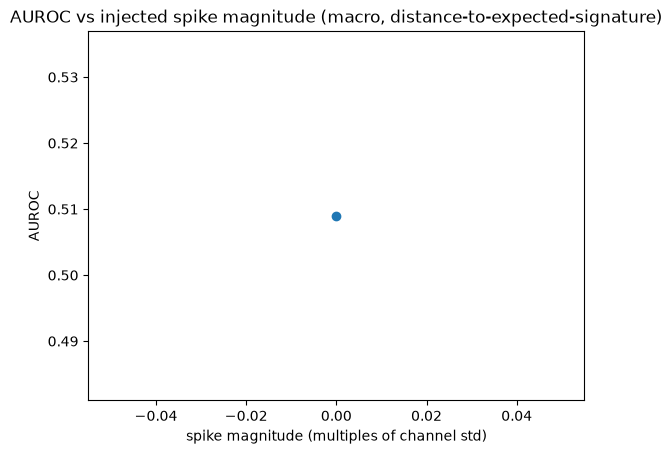

{np.float64(0.0): 0.509,
 np.float64(2.7873386464970857): 0.49390000000000006,
 np.float64(5.5746772929941715): 0.5928000000000001,
 np.float64(11.149354585988343): 0.7393000000000001,
 np.float64(22.298709171976686): 0.8816,
 np.float64(44.59741834395337): 0.9788}

In [2]:
from src.evaluation.synthetic import auroc_vs_spike_magnitude

channel = macro_cfg.channels.index('log_return')
# Calibrate spike magnitudes to this channel's own natural scale --
# fixed absolute values (e.g. 0.05-0.8) turned out to be negligible noise
# next to real BTC 30-day cumulative log-return swings (std ~3 in
# normalized units here), which silently produced a flat/noisy AUROC.
channel_std = np.std([p[-1, channel] for p in ref_paths])
magnitudes = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]
magnitudes = [m * channel_std for m in magnitudes]
print('channel std:', channel_std, '-> magnitudes:', magnitudes)

results = auroc_vs_spike_magnitude(
    calib_paths, model.score, channel=channel,
    magnitudes=magnitudes, n_per_class=100, seed=0,
)
pd.Series(results, index=[0.0, 0.5, 1.0, 2.0, 4.0, 8.0]).plot(
    marker='o', title='AUROC vs injected spike magnitude (macro, distance-to-expected-signature)'
)
plt.xlabel('spike magnitude (multiples of channel std)'); plt.ylabel('AUROC')
plt.savefig('../reports/synthetic_auroc_macro.png', dpi=120)
plt.show()
results

**Check before proceeding:** AUROC should trend upward with magnitude. If it doesn't, revisit the feature pipeline / model fit before trusting anything below.

## Step 2: historical event detection

In [3]:
all_end_times, all_raw = raw_paths_for_horizon(daily, macro_cfg)
all_paths = [add_basepoint(normalize(p, scale)) for p in all_raw]
full_model = ExpectedSignatureDistance(depth=macro_cfg.depth).fit(train_paths)
score_series = pd.Series(full_model.score_many(all_paths), index=pd.DatetimeIndex(all_end_times))

from src.models.tail_bounds import fit_weibull_tail, weibull_threshold
# Calibrated on calib_paths -- genuinely held-out from full_model's own
# training data, not the same windows it was fit on (the prior single-period
# setup's threshold was calibrated in-sample; this is the fix for that).
calib_scores = full_model.score_many(calib_paths)
A, B = fit_weibull_tail(calib_scores, N=macro_cfg.depth)
threshold = weibull_threshold(0.01, A, B, N=macro_cfg.depth)
print('alpha=0.01 threshold:', threshold)

alpha=0.01 threshold: 4577.601711520159


In [4]:
from src.evaluation.events import evaluate_all_events

event_results = evaluate_all_events(score_series, threshold, cfg['events'])
print('false positive rate outside events:', event_results.attrs['false_positive_rate'])
event_results

false positive rate outside events: 0.21588089330024815


,detected,lag,first_crossing_time
event,,,
covid_crash,True,27 days,2020-03-18 00:00:00+00:00
meme_stock_era_btc_runup_crash,True,1 days,2021-01-02 00:00:00+00:00
crypto_crash_terra_luna,True,16 days,2022-05-17 00:00:00+00:00
crypto_crash_ftx,True,12 days,2022-11-13 00:00:00+00:00
banking_crisis_2023,False,NaT,NaT


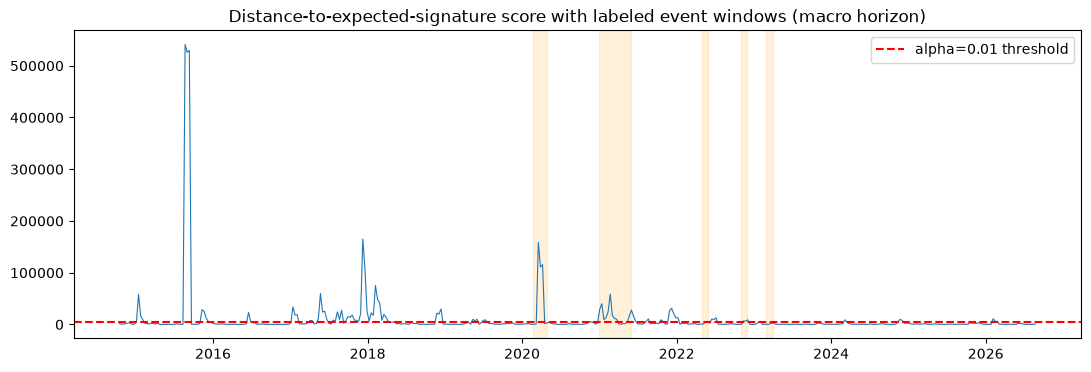

In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(score_series.index, score_series.values, lw=0.8)
ax.axhline(threshold, color='red', ls='--', label=f'alpha=0.01 threshold')
for name, ev in cfg['events'].items():
    ax.axvspan(pd.Timestamp(ev['start'], tz='UTC'), pd.Timestamp(ev['end'], tz='UTC'), alpha=0.15, color='orange')
ax.legend()
ax.set_title('Distance-to-expected-signature score with labeled event windows (macro horizon)')
plt.savefig('../reports/event_detection_macro.png', dpi=120)
plt.show()

## Step 3: bull/bear and volatility regime transitions

In [6]:
from src.evaluation.regimes import bull_bear_labels, volatility_regime_labels, regime_transition_dates, score_near_transitions

close = daily['close']
bull_bear = bull_bear_labels(close)
vol_regime = volatility_regime_labels(close)

bull_bear_transitions = regime_transition_dates(bull_bear.dropna())
vol_transitions = regime_transition_dates(vol_regime.dropna())
print('bull/bear transitions:', len(bull_bear_transitions))
print('vol regime transitions:', len(vol_transitions))

hit_rate_bull_bear = score_near_transitions(score_series, bull_bear_transitions, pd.Timedelta(days=15), threshold)
hit_rate_vol = score_near_transitions(score_series, vol_transitions, pd.Timedelta(days=15), threshold)
print(f'bull/bear transition hit rate (±15d): {hit_rate_bull_bear:.2%}')
print(f'vol regime transition hit rate (±15d): {hit_rate_vol:.2%}')

bull/bear transitions: 76
vol regime transitions: 167
bull/bear transition hit rate (±15d): 28.95%
vol regime transition hit rate (±15d): 57.49%


## Step 3b: event-validating the other paper-faithful measures

`conformance_score` and `cvar_ocsvm` were computed for all 434 macro windows back in notebook 04, but never run through the same synthetic-AUROC / event-detection / regime-hit-rate checks used above for distance-to-expected-signature. Same recipe, same reference windows, same alpha=0.01 target -- so all three measures land in one comparable table in Step 4.

In [7]:
from src.models.conformance import ConformanceScore

# Synthetic sanity check first (mirrors Step 1, model fit on train_paths only)
conf_train_model = ConformanceScore(depth=macro_cfg.depth).fit(train_paths)
conf_synth_results = auroc_vs_spike_magnitude(
    calib_paths, conf_train_model.score, channel=channel,
    magnitudes=magnitudes, n_per_class=100, seed=0,
)
print('conformance synthetic AUROC vs spike magnitude:', conf_synth_results)

# Real event detection (mirrors Step 2: fit on train_paths, calibrate on the
# genuinely held-out calib_paths -- not the same windows it was fit on)
conf_model = ConformanceScore(depth=macro_cfg.depth).fit(train_paths)
conf_score_series = pd.Series(conf_model.score_many(all_paths), index=pd.DatetimeIndex(all_end_times))
conf_calib = conf_model.score_many(calib_paths)

# The Weibull tail fit can still come back degenerate or fail outright on a
# small/awkward calibration sample -- fall back to the empirical max in that
# case (see Step 2's threshold cell for the same pattern).
try:
    conf_A, conf_B = fit_weibull_tail(conf_calib, N=macro_cfg.depth)
    conf_threshold = weibull_threshold(0.01, conf_A, conf_B, N=macro_cfg.depth)
    print('conformance alpha=0.01 threshold (Weibull):', conf_threshold)
except (ValueError, TypeError) as e:
    print(f'conformance Weibull tail fit/threshold failed ({e!r}); falling back to max(calibration scores)')
    conf_threshold = float(conf_calib.max())
print('conformance threshold used:', conf_threshold)

conf_event_results = evaluate_all_events(conf_score_series, conf_threshold, cfg['events'])
print('conformance false positive rate outside events:', conf_event_results.attrs['false_positive_rate'])
conf_event_results

conformance synthetic AUROC vs spike magnitude: {np.float64(0.0): 0.5056, np.float64(2.7873386464970857): 0.4894, np.float64(5.5746772929941715): 0.5976, np.float64(11.149354585988343): 0.7259, np.float64(22.298709171976686): 0.8764000000000001, np.float64(44.59741834395337): 0.9764}


conformance alpha=0.01 threshold (Weibull): 152.32076844451393
conformance threshold used: 152.32076844451393
conformance false positive rate outside events: 0.20595533498759305


,detected,lag,first_crossing_time
event,,,
covid_crash,True,27 days,2020-03-18 00:00:00+00:00
meme_stock_era_btc_runup_crash,True,1 days,2021-01-02 00:00:00+00:00
crypto_crash_terra_luna,True,16 days,2022-05-17 00:00:00+00:00
crypto_crash_ftx,True,12 days,2022-11-13 00:00:00+00:00
banking_crisis_2023,False,NaT,NaT


In [8]:
conf_hit_rate_bull_bear = score_near_transitions(conf_score_series, bull_bear_transitions, pd.Timedelta(days=15), conf_threshold)
conf_hit_rate_vol = score_near_transitions(conf_score_series, vol_transitions, pd.Timedelta(days=15), conf_threshold)
print(f'conformance bull/bear transition hit rate (±15d): {conf_hit_rate_bull_bear:.2%}')
print(f'conformance vol regime transition hit rate (±15d): {conf_hit_rate_vol:.2%}')

conformance bull/bear transition hit rate (±15d): 28.95%
conformance vol regime transition hit rate (±15d): 55.09%


In [9]:
from src.models.cvar_ocsvm import CVaROCSVM
from src.features.signatures import signature as _signature

# CVaR-OCSVM is deliberately run at a smaller signature depth than the other
# models (see src/models/cvar_ocsvm.py docstring) -- the shuffle-power terms
# need the expected signature up to level ocsvm_depth*poly_degree, which
# grows combinatorially. K (the polynomial-approximation range) is sized
# adaptively from whichever training set is used, same recipe as notebook 04.
ocsvm_depth = 2
d_channels = len(macro_cfg.channels)

def fit_cvar_model(paths):
    train_sigs_depth2 = np.vstack([_signature(p, ocsvm_depth) for p in paths])
    K = 3.0 * np.abs(train_sigs_depth2).max()
    m = CVaROCSVM(ocsvm_depth=ocsvm_depth, d=d_channels, alpha=0.9, K=K, poly_degree=2).fit(paths)
    return m, K

# Synthetic sanity check (train_paths fit, mirrors Step 1)
cvar_train_model, cvar_train_K = fit_cvar_model(train_paths)
print('CVaR-OCSVM (train fit) converged:', cvar_train_model.optim_result_.success,
      'rho:', cvar_train_model.rho_, '(K was', cvar_train_K, ')')
cvar_synth_results = auroc_vs_spike_magnitude(
    calib_paths, cvar_train_model.score, channel=channel,
    magnitudes=magnitudes, n_per_class=100, seed=0,
)
print('CVaR-OCSVM synthetic AUROC vs spike magnitude:', cvar_synth_results)

# Real event detection: fit on train_paths, calibrate on held-out calib_paths
# (mirrors Step 2's fix -- no longer in-sample)
cvar_full_model, cvar_K = fit_cvar_model(train_paths)
print('CVaR-OCSVM (event-detection fit) converged:', cvar_full_model.optim_result_.success,
      'rho:', cvar_full_model.rho_, '(K was', cvar_K, ')')
cvar_score_series = pd.Series(cvar_full_model.score_many(all_paths), index=pd.DatetimeIndex(all_end_times))
cvar_calib = cvar_full_model.score_many(calib_paths)

# Unlike expected-signature-distance/conformance (always >=0 by construction,
# a norm/Mahalanobis distance), CVaR-OCSVM's score is a signed decision-function
# value (rho* - <w*,S(x)>) that can be negative for "normal" calibration points.
# The paper's Weibull tail model P(score>r) ~ A*exp(-B*r^(2/N)) assumes a
# one-sided, nonnegative-supported tail, so it can fail outright (no positive
# tail scores to fit) or return a degenerate fit. Fall back to the empirical
# max of the calibration scores in either case.
try:
    cvar_A, cvar_B = fit_weibull_tail(cvar_calib, N=ocsvm_depth)
    cvar_threshold = weibull_threshold(0.01, cvar_A, cvar_B, N=ocsvm_depth)
    print('CVaR-OCSVM alpha=0.01 threshold (Weibull):', cvar_threshold)
except (ValueError, TypeError) as e:
    print(f'CVaR-OCSVM Weibull tail fit/threshold failed ({e!r}); falling back to max(calibration scores). '
          'CVaR-OCSVM scores can be negative for normal points, which the one-sided Weibull tail model assumes away.')
    cvar_threshold = float(cvar_calib.max())
print('CVaR-OCSVM threshold used:', cvar_threshold)

cvar_event_results = evaluate_all_events(cvar_score_series, cvar_threshold, cfg['events'])
print('CVaR-OCSVM false positive rate outside events:', cvar_event_results.attrs['false_positive_rate'])
cvar_event_results

CVaR-OCSVM (train fit) converged: True rho: 88.56204017622345 (K was 283.24888173240817 )


CVaR-OCSVM synthetic AUROC vs spike magnitude: {np.float64(0.0): 0.489, np.float64(2.7873386464970857): 0.46420000000000006, np.float64(5.5746772929941715): 0.3594, np.float64(11.149354585988343): 0.19380000000000003, np.float64(22.298709171976686): 0.09140000000000001, np.float64(44.59741834395337): 0.0127}


CVaR-OCSVM (event-detection fit) converged: True rho: 88.56204017622345 (K was 283.24888173240817 )
CVaR-OCSVM Weibull tail fit/threshold failed (ValueError('alpha must be in (0, 1.1618118021895823e-05) for this fitted tail')); falling back to max(calibration scores). CVaR-OCSVM scores can be negative for normal points, which the one-sided Weibull tail model assumes away.
CVaR-OCSVM threshold used: 87.1439135226396


CVaR-OCSVM false positive rate outside events: 0.02977667493796526


,detected,lag,first_crossing_time
event,,,
covid_crash,False,None,None
meme_stock_era_btc_runup_crash,False,None,None
crypto_crash_terra_luna,False,None,None
crypto_crash_ftx,False,None,None
banking_crisis_2023,False,None,None


In [10]:
cvar_hit_rate_bull_bear = score_near_transitions(cvar_score_series, bull_bear_transitions, pd.Timedelta(days=15), cvar_threshold)
cvar_hit_rate_vol = score_near_transitions(cvar_score_series, vol_transitions, pd.Timedelta(days=15), cvar_threshold)
print(f'CVaR-OCSVM bull/bear transition hit rate (±15d): {cvar_hit_rate_bull_bear:.2%}')
print(f'CVaR-OCSVM vol regime transition hit rate (±15d): {cvar_hit_rate_vol:.2%}')

CVaR-OCSVM bull/bear transition hit rate (±15d): 2.63%
CVaR-OCSVM vol regime transition hit rate (±15d): 5.99%


## Step 4: summary table

Repeat steps 1-3 for the intraday and micro horizons and for the other models (baselines + conformance score + CVaR-OCSVM) to fill this out fully -- this cell shows the pattern for one horizon/model pair.

In [11]:
from src.evaluation.metrics import summarize_horizon_model

summary_rows = [
    summarize_horizon_model('macro', 'expected_signature_distance', results, event_results, hit_rate_bull_bear),
    summarize_horizon_model('macro', 'conformance_score', conf_synth_results, conf_event_results, conf_hit_rate_bull_bear),
    summarize_horizon_model('macro', 'cvar_ocsvm', cvar_synth_results, cvar_event_results, cvar_hit_rate_bull_bear),
]
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('../reports/summary_table.csv', index=False)
summary_df

,horizon,model,synthetic_auroc_max,synthetic_auroc_at_smallest_magnitude,events_detected,events_total,false_positive_rate,regime_transition_hit_rate
0,macro,expected_signature_distance,0.9788,0.5090,4,5,0.215881,0.289474
1,macro,conformance_score,0.9764,0.5056,4,5,0.205955,0.289474
2,macro,cvar_ocsvm,0.4890,0.4890,0,5,0.029777,0.026316


## Step 5: daily scoring with recency-weighted windows

Everything above scores once every 10 days (macro's `step`). Here the same distance-to-expected-signature statistic is refit with each window's increments reweighted by recency (exponential decay, half-life from `configs/horizons.yaml`'s `recency_halflife_days`) and scored on the `macro_daily` horizon (`step=1`) -- one score per calendar day instead of one per 10 days.

Calibration (fitting "normal," the Weibull tail) deliberately stays on the coarser `macro` step's train/calib windows, not the daily ones -- adjacent step=1 windows share 29 of their 30 days, so treating them as independent calibration samples would badly corrupt the tail fit. Only the *scored* series goes daily; recency weighting is applied identically to the reference paths used to fit/calibrate and to the live-scored daily windows, per `apply_recency_weights`'s own docstring.

In [12]:
from src.paths.transforms import apply_recency_weights

halflife = cfg['recency_halflife_days']
macro_daily_cfg = HorizonConfig.from_dict('macro_daily', cfg['horizons']['macro_daily'])

def prep_weighted(paths):
    return [add_basepoint(apply_recency_weights(normalize(p, scale), halflife)) for p in paths]

train_paths_w = prep_weighted(train_raw)
calib_paths_w = prep_weighted(calib_raw)

daily_end_times, daily_raw = raw_paths_for_horizon(daily, macro_daily_cfg)
daily_paths_w = prep_weighted(daily_raw)

weighted_model = ExpectedSignatureDistance(depth=macro_cfg.depth).fit(train_paths_w)
daily_score_series = pd.Series(weighted_model.score_many(daily_paths_w), index=pd.DatetimeIndex(daily_end_times))

weighted_calib = weighted_model.score_many(calib_paths_w)
w_A, w_B = fit_weibull_tail(weighted_calib, N=macro_cfg.depth)
daily_threshold = weibull_threshold(0.01, w_A, w_B, N=macro_cfg.depth)
print(f'{len(daily_paths_w)} daily-scored windows (step=1), halflife={halflife}d, '
      f'alpha=0.01 threshold={daily_threshold}')

4340 daily-scored windows (step=1), halflife=8d, alpha=0.01 threshold=1572.4866931244344


In [13]:
weighted_synth_results = auroc_vs_spike_magnitude(
    calib_paths_w, weighted_model.score, channel=channel,
    magnitudes=magnitudes, n_per_class=100, seed=0,
)
print('recency-weighted synthetic AUROC vs spike magnitude:', weighted_synth_results)

recency-weighted synthetic AUROC vs spike magnitude: {np.float64(0.0): 0.4849, np.float64(2.7873386464970857): 0.5307999999999999, np.float64(5.5746772929941715): 0.6220000000000001, np.float64(11.149354585988343): 0.8613, np.float64(22.298709171976686): 0.9825999999999999, np.float64(44.59741834395337): 0.9972}


In [14]:
from src.evaluation.events import false_positive_rate_outside_events

# Primary series is now the daily one itself (detected/lag computed at daily
# granularity) -- daily_score_series/daily_threshold are passed again to also
# populate the day_flag_rate column (a *further* statistic even once the
# primary series is already daily: what fraction of the event's days crossed,
# not just whether any did).
event_results_daily = evaluate_all_events(
    daily_score_series, daily_threshold, cfg['events'],
    daily_score_series=daily_score_series, daily_threshold=daily_threshold,
)
print('false positive rate outside events (daily, recency-weighted series):',
      event_results_daily.attrs['false_positive_rate'])
event_results_daily[['detected', 'lag', 'day_flag_rate', 'first_flagged_day']]

false positive rate outside events (daily, recency-weighted series): 0.06035767511177347


,detected,lag,day_flag_rate,first_flagged_day
event,,,,
covid_crash,True,21 days,0.239437,2020-03-12 00:00:00+00:00
meme_stock_era_btc_runup_crash,True,1 days,0.403974,2021-01-02 00:00:00+00:00
crypto_crash_terra_luna,True,8 days,0.064516,2022-05-09 00:00:00+00:00
crypto_crash_ftx,True,8 days,0.133333,2022-11-09 00:00:00+00:00
banking_crisis_2023,False,NaT,0.000000,NaT


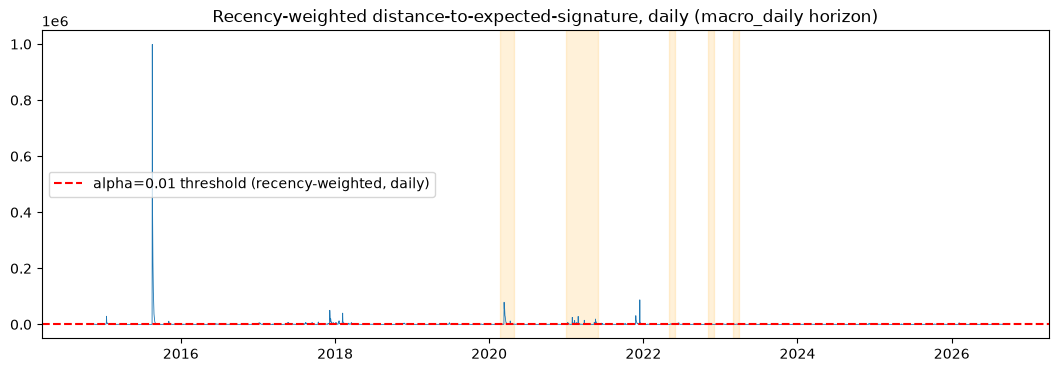

daily/recency-weighted bull/bear transition hit rate (±15d): 38.16%
daily/recency-weighted vol regime transition hit rate (±15d): 47.90%


In [15]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily_score_series.index, daily_score_series.values, lw=0.6)
ax.axhline(daily_threshold, color='red', ls='--', label='alpha=0.01 threshold (recency-weighted, daily)')
for name, ev in cfg['events'].items():
    ax.axvspan(pd.Timestamp(ev['start'], tz='UTC'), pd.Timestamp(ev['end'], tz='UTC'), alpha=0.15, color='orange')
ax.legend()
ax.set_title('Recency-weighted distance-to-expected-signature, daily (macro_daily horizon)')
plt.savefig('../reports/event_detection_macro_daily.png', dpi=120)
plt.show()

daily_hit_rate_bull_bear = score_near_transitions(daily_score_series, bull_bear_transitions, pd.Timedelta(days=15), daily_threshold)
daily_hit_rate_vol = score_near_transitions(daily_score_series, vol_transitions, pd.Timedelta(days=15), daily_threshold)
print(f'daily/recency-weighted bull/bear transition hit rate (±15d): {daily_hit_rate_bull_bear:.2%}')
print(f'daily/recency-weighted vol regime transition hit rate (±15d): {daily_hit_rate_vol:.2%}')

## Step 6: updated summary table (all four measures, including daily/recency-weighted)

In [16]:
summary_rows = [
    summarize_horizon_model('macro', 'expected_signature_distance', results, event_results, hit_rate_bull_bear),
    summarize_horizon_model('macro', 'conformance_score', conf_synth_results, conf_event_results, conf_hit_rate_bull_bear),
    summarize_horizon_model('macro', 'cvar_ocsvm', cvar_synth_results, cvar_event_results, cvar_hit_rate_bull_bear),
    summarize_horizon_model('macro_daily', 'expected_signature_distance_recency_weighted',
                             weighted_synth_results, event_results_daily, daily_hit_rate_bull_bear),
]
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('../reports/summary_table.csv', index=False)
summary_df

,horizon,model,synthetic_auroc_max,synthetic_auroc_at_smallest_magnitude,events_detected,events_total,false_positive_rate,regime_transition_hit_rate
0,macro,expected_signature_distance,0.9788,0.5090,4,5,0.215881,0.289474
1,macro,conformance_score,0.9764,0.5056,4,5,0.205955,0.289474
2,macro,cvar_ocsvm,0.4890,0.4890,0,5,0.029777,0.026316
3,macro_daily,expected_signature_distance_recency_weighted,0.9972,0.4849,4,5,0.060358,0.381579


## Step 7: broader anomaly-detection methods (breadth, not just more measures)

Everything above stays inside the path-signature representation -- different scoring functions on the same signature feature vector. This section is a genuine breadth check on whether signatures are even the right representation: classical engineered features (no signatures at all) fed to the existing sklearn baselines and to PyOD's ECOD, a matrix-profile discord score (`stumpy`), a hand-rolled Gaussian-HMM regime-switcher, and `ruptures` changepoint detection.

Thresholds for every new method here use a simple empirical 99th-percentile-of-the-reference-scores cut (not the paper's Weibull tail fit) -- these scores don't necessarily follow that parametric family, and an empirical percentile is the more honest choice than forcing a fit that may not apply.

In [17]:
from src.features.engineered import build_engineered_features, FEATURE_NAMES

eng_features = build_engineered_features(daily, macro_cfg.window, macro_cfg.step)
eng_train_mask = pd.Series(False, index=eng_features.index)
for p in periods:
    eng_train_mask |= (eng_features.index >= pd.Timestamp(p['start'], tz='UTC')) & \
                       (eng_features.index <= pd.Timestamp(p['end'], tz='UTC'))
eng_X_train = eng_features.loc[eng_train_mask].to_numpy()
eng_X_all = eng_features.to_numpy()
print('engineered features:', eng_features.shape, '| reference/train rows:', eng_X_train.shape[0])
eng_features.head()

engineered features: (434, 7) | reference/train rows: 164


,realized_vol,skew,kurtosis,total_return,max_drawdown,mean_volume,mean_range
window_end,,,,,,,
2014-10-16 00:00:00+00:00,0.039390,-0.089748,-0.393681,-0.178539,-0.355501,3.624856e+07,0.063999
2014-10-26 00:00:00+00:00,0.032749,-0.614079,0.012043,-0.118980,-0.220350,3.090157e+07,0.055845
2014-11-05 00:00:00+00:00,0.028099,-0.565040,0.017933,0.009765,-0.207510,2.294106e+07,0.044516
2014-11-15 00:00:00+00:00,0.039270,1.209062,3.872240,-0.020069,-0.183710,1.882756e+07,0.046427
2014-11-25 00:00:00+00:00,0.040042,1.016534,3.026095,0.061417,-0.188344,2.222207e+07,0.051458


In [18]:
from sklearn.preprocessing import StandardScaler
from src.models.baselines import fit_sklearn_baselines, score_sklearn_baselines

eng_scaler = StandardScaler().fit(eng_X_train)
eng_train_scaled = eng_scaler.transform(eng_X_train)
eng_all_scaled = eng_scaler.transform(eng_X_all)

eng_models = fit_sklearn_baselines(eng_train_scaled)
eng_scores = score_sklearn_baselines(eng_models, eng_all_scaled)

breadth_summary_rows = []
for name, score_arr in eng_scores.items():
    s = pd.Series(score_arr, index=eng_features.index)
    train_scores = s.loc[eng_train_mask]
    thr = float(np.quantile(train_scores, 0.99))
    ev = evaluate_all_events(s, thr, cfg['events'])
    hit = score_near_transitions(s, bull_bear_transitions, pd.Timedelta(days=15), thr)
    print(f'{name}: threshold={thr:.4f}, events detected={int(ev["detected"].sum())}/5, '
          f'FPR={ev.attrs["false_positive_rate"]:.4f}')
    breadth_summary_rows.append(
        summarize_horizon_model('macro_engineered', f'sklearn_{name}', None, ev, hit)
    )

one_class_svm: threshold=0.0003, events detected=5/5, FPR=0.3449
isolation_forest: threshold=0.1593, events detected=2/5, FPR=0.0769
local_outlier_factor: threshold=0.3679, events detected=2/5, FPR=0.1588
elliptic_envelope: threshold=144.3122, events detected=1/5, FPR=0.0323


In [19]:
from pyod.models.ecod import ECOD

# ECOD: distribution-free (empirical-CDF-based), explicitly marketed as
# robust to heavy tails -- directly relevant given this project's own
# documented fat-tailed-BTC-returns problem (the CVaR-OCSVM instability
# root cause). Also on engineered features, not signatures.
ecod = ECOD().fit(eng_train_scaled)
ecod_scores = pd.Series(ecod.decision_function(eng_all_scaled), index=eng_features.index)
ecod_train_scores = ecod_scores.loc[eng_train_mask]
ecod_thr = float(np.quantile(ecod_train_scores, 0.99))

ecod_ev = evaluate_all_events(ecod_scores, ecod_thr, cfg['events'])
ecod_hit = score_near_transitions(ecod_scores, bull_bear_transitions, pd.Timedelta(days=15), ecod_thr)
print(f'ECOD: threshold={ecod_thr:.4f}, events detected={int(ecod_ev["detected"].sum())}/5, '
      f'FPR={ecod_ev.attrs["false_positive_rate"]:.4f}')
breadth_summary_rows.append(summarize_horizon_model('macro_engineered', 'pyod_ecod', None, ecod_ev, ecod_hit))
ecod_ev

ECOD: threshold=21.0773, events detected=1/5, FPR=0.0174


,detected,lag,first_crossing_time
event,,,
covid_crash,True,27 days,2020-03-18 00:00:00+00:00
meme_stock_era_btc_runup_crash,False,NaT,NaT
crypto_crash_terra_luna,False,NaT,NaT
crypto_crash_ftx,False,NaT,NaT
banking_crisis_2023,False,NaT,NaT


In [20]:
import stumpy

# Matrix profile: per-day-native discord detection directly on the raw
# log-return series -- no windowing/signature step of our own at all.
# Subsequence length m matches the macro window (30). mp[i,0] is the
# distance from the subsequence starting at log-return index i to its
# nearest neighbor elsewhere in the series; a large distance means that
# subsequence looks like nothing else in the data (a discord).
log_ret_full = np.diff(np.log(daily['close'].to_numpy(dtype=float)))
m = macro_cfg.window
mp = stumpy.stump(log_ret_full, m)
mp_dist = mp[:, 0].astype(float)
mp_end_idx = np.arange(len(mp_dist)) + m  # align each profile value to its subsequence's end date
mp_series = pd.Series(mp_dist, index=daily.index[mp_end_idx])

mp_train_mask = pd.Series(False, index=mp_series.index)
for p in periods:
    mp_train_mask |= (mp_series.index >= pd.Timestamp(p['start'], tz='UTC')) & \
                      (mp_series.index <= pd.Timestamp(p['end'], tz='UTC'))
mp_thr = float(np.quantile(mp_series.loc[mp_train_mask], 0.99))

mp_ev = evaluate_all_events(mp_series, mp_thr, cfg['events'])
mp_hit = score_near_transitions(mp_series, bull_bear_transitions, pd.Timedelta(days=15), mp_thr)
print(f'Matrix profile: threshold={mp_thr:.4f}, events detected={int(mp_ev["detected"].sum())}/5, '
      f'FPR={mp_ev.attrs["false_positive_rate"]:.4f}')
breadth_summary_rows.append(summarize_horizon_model('macro', 'matrix_profile_stumpy', None, mp_ev, mp_hit))
mp_ev

Matrix profile: threshold=5.1926, events detected=1/5, FPR=0.0114


,detected,lag,first_crossing_time
event,,,
covid_crash,True,5 days,2020-02-25 00:00:00+00:00
meme_stock_era_btc_runup_crash,False,NaT,NaT
crypto_crash_terra_luna,False,NaT,NaT
crypto_crash_ftx,False,NaT,NaT
banking_crisis_2023,False,NaT,NaT


In [21]:
from src.models.gaussian_hmm import GaussianHMM

# Regime-switching baseline: fit directly on daily [log_return, log_range]
# from the pooled reference periods (concatenated -- a handful of spurious
# "transitions" at the ~13 period boundaries is a small, accepted
# approximation, not a full multi-sequence EM). No signatures involved.
close = daily['close'].to_numpy(dtype=float)
high = daily['high'].to_numpy(dtype=float)
low = daily['low'].to_numpy(dtype=float)
daily_log_ret = np.diff(np.log(close), prepend=np.log(close[0]))
daily_log_range = np.log(high) - np.log(low)
hmm_features_full = np.column_stack([daily_log_ret, daily_log_range])

hmm_train_mask_days = pd.Series(False, index=daily.index)
for p in periods:
    hmm_train_mask_days |= (daily.index >= pd.Timestamp(p['start'], tz='UTC')) & \
                            (daily.index <= pd.Timestamp(p['end'], tz='UTC'))
hmm_train_X = hmm_features_full[hmm_train_mask_days.to_numpy()]

hmm = GaussianHMM(n_states=2, n_iter=200, seed=0).fit(hmm_train_X)
hv = hmm.high_vol_state()
hmm_post_full = hmm.state_posteriors(hmm_features_full)[:, hv]
hmm_series = pd.Series(hmm_post_full, index=daily.index)

hmm_ev = evaluate_all_events(hmm_series, 0.5, cfg['events'])
hmm_hit = score_near_transitions(hmm_series, bull_bear_transitions, pd.Timedelta(days=15), 0.5)
print(f'Gaussian HMM: high-vol state variances={hmm.variances_[hv]}, threshold=0.5 (posterior), '
      f'events detected={int(hmm_ev["detected"].sum())}/5, FPR={hmm_ev.attrs["false_positive_rate"]:.4f}')
breadth_summary_rows.append(summarize_horizon_model('macro', 'gaussian_hmm', None, hmm_ev, hmm_hit))
hmm_ev

Gaussian HMM: high-vol state variances=[0.00100854 0.00045105], threshold=0.5 (posterior), events detected=5/5, FPR=0.5618


,detected,lag,first_crossing_time
event,,,
covid_crash,True,3 days,2020-02-23 00:00:00+00:00
meme_stock_era_btc_runup_crash,True,0 days,2021-01-01 00:00:00+00:00
crypto_crash_terra_luna,True,0 days,2022-05-01 00:00:00+00:00
crypto_crash_ftx,True,3 days,2022-11-04 00:00:00+00:00
banking_crisis_2023,True,0 days,2023-03-01 00:00:00+00:00


In [22]:
import ruptures as rpt

# Changepoint detection answers a different question than the other methods
# here: not "is this point anomalous" but "where did the regime shift."
# Cross-checked against events directly (nearest changepoint to each event's
# start) rather than forced into the threshold/score contract the other
# methods share.
algo = rpt.Pelt(model='rbf').fit(daily_log_ret.reshape(-1, 1))
breakpoints = algo.predict(pen=10)
breakpoint_dates = daily.index[[b for b in breakpoints if b < len(daily.index)]]
print(f'{len(breakpoint_dates)} changepoints detected over the full history')

rows = []
for name, ev in cfg['events'].items():
    ev_start = pd.Timestamp(ev['start'], tz='UTC')
    ev_end = pd.Timestamp(ev['end'], tz='UTC')
    nearby = breakpoint_dates[(breakpoint_dates >= ev_start - pd.Timedelta(days=15)) &
                              (breakpoint_dates <= ev_end + pd.Timedelta(days=15))]
    if len(nearby):
        lag = (nearby[0] - ev_start)
        rows.append({'event': name, 'changepoint_nearby': True, 'lag': lag, 'first_changepoint': nearby[0]})
    else:
        rows.append({'event': name, 'changepoint_nearby': False, 'lag': pd.NaT, 'first_changepoint': None})
rpt_results = pd.DataFrame(rows).set_index('event')
print(f'changepoints within ±15d of event start/end: {rpt_results["changepoint_nearby"].sum()}/5')
rpt_results

3 changepoints detected over the full history
changepoints within ±15d of event start/end: 0/5


,changepoint_nearby,lag,first_changepoint
event,,,
covid_crash,False,NaT,None
meme_stock_era_btc_runup_crash,False,NaT,None
crypto_crash_terra_luna,False,NaT,None
crypto_crash_ftx,False,NaT,None
banking_crisis_2023,False,NaT,None


## Step 8: complete summary (signature measures + broader methods)

`ruptures` isn't in this table -- changepoint detection doesn't share the continuous-score-plus-threshold contract the other rows do (see Step 7's own printout for its results).

In [23]:
summary_rows = summary_rows + breadth_summary_rows
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('../reports/summary_table.csv', index=False)
summary_df

,horizon,model,synthetic_auroc_max,synthetic_auroc_at_smallest_magnitude,events_detected,events_total,false_positive_rate,regime_transition_hit_rate
0,macro,expected_signature_distance,0.9788,0.5090,4,5,0.215881,0.289474
1,macro,conformance_score,0.9764,0.5056,4,5,0.205955,0.289474
2,macro,cvar_ocsvm,0.4890,0.4890,0,5,0.029777,0.026316
3,macro_daily,expected_signature_distance_recency_weighted,0.9972,0.4849,4,5,0.060358,0.381579
4,macro_engineered,sklearn_one_class_svm,NaN,NaN,5,5,0.344913,0.592105
5,macro_engineered,sklearn_isolation_forest,NaN,NaN,2,5,0.076923,0.157895
6,macro_engineered,sklearn_local_outlier_factor,NaN,NaN,2,5,0.158809,0.171053
7,macro_engineered,sklearn_elliptic_envelope,NaN,NaN,1,5,0.032258,0.092105
8,macro_engineered,pyod_ecod,NaN,NaN,1,5,0.017370,0.118421
9,macro,matrix_profile_stumpy,NaN,NaN,1,5,0.011429,0.223684


## Step 9: Signature-MMD (a new "measure," same signature features)

A June 2025 result (Alden, Horvath & Issa, arXiv:2506.01718) frames novelty detection as a two-sample MMD test in signature-kernel space, rather than distance-to-a-single-mean. Implemented here using the already-computed truncated signature feature vectors as an explicit (linear-kernel) feature map -- see `src/models/signature_mmd.py`'s docstring for the honest caveat this implies (mean-shift-only, not the fully general nonlinear signature kernel). What it adds over distance-to-expected-signature: each score compares a trailing *batch* of windows against the reference, not one window alone -- a sustained-shift detector rather than a single-point one.

In [24]:
from src.models.signature_mmd import SignatureMMD

mmd_model = SignatureMMD(depth=macro_cfg.depth, batch_size=5).fit(train_paths)
mmd_scores_all = pd.Series(mmd_model.score_series(all_paths), index=pd.DatetimeIndex(all_end_times))
mmd_scores_calib = mmd_model.score_series(calib_paths)
mmd_thr = float(np.quantile(mmd_scores_calib, 0.99))

mmd_ev = evaluate_all_events(mmd_scores_all, mmd_thr, cfg['events'])
mmd_hit = score_near_transitions(mmd_scores_all, bull_bear_transitions, pd.Timedelta(days=15), mmd_thr)
print(f'Signature-MMD: threshold={mmd_thr:.4f}, events detected={int(mmd_ev["detected"].sum())}/5, '
      f'FPR={mmd_ev.attrs["false_positive_rate"]:.4f}')

mmd_synth_results = auroc_vs_spike_magnitude(
    calib_paths, lambda p: mmd_model.score_series([p])[0], channel=channel,
    magnitudes=magnitudes, n_per_class=100, seed=0,
)
print('Signature-MMD synthetic AUROC vs spike magnitude:', mmd_synth_results)

summary_rows.append(summarize_horizon_model('macro', 'signature_mmd', mmd_synth_results, mmd_ev, mmd_hit))
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('../reports/summary_table.csv', index=False)
summary_df

Signature-MMD: threshold=3133255.6065, events detected=4/5, FPR=0.3176


Signature-MMD synthetic AUROC vs spike magnitude: {np.float64(0.0): 0.509, np.float64(2.7873386464970857): 0.49390000000000006, np.float64(5.5746772929941715): 0.5928000000000001, np.float64(11.149354585988343): 0.7393000000000001, np.float64(22.298709171976686): 0.8816, np.float64(44.59741834395337): 0.9788}


,horizon,model,synthetic_auroc_max,synthetic_auroc_at_smallest_magnitude,events_detected,events_total,false_positive_rate,regime_transition_hit_rate
0,macro,expected_signature_distance,0.9788,0.5090,4,5,0.215881,0.289474
1,macro,conformance_score,0.9764,0.5056,4,5,0.205955,0.289474
2,macro,cvar_ocsvm,0.4890,0.4890,0,5,0.029777,0.026316
3,macro_daily,expected_signature_distance_recency_weighted,0.9972,0.4849,4,5,0.060358,0.381579
4,macro_engineered,sklearn_one_class_svm,NaN,NaN,5,5,0.344913,0.592105
5,macro_engineered,sklearn_isolation_forest,NaN,NaN,2,5,0.076923,0.157895
6,macro_engineered,sklearn_local_outlier_factor,NaN,NaN,2,5,0.158809,0.171053
7,macro_engineered,sklearn_elliptic_envelope,NaN,NaN,1,5,0.032258,0.092105
8,macro_engineered,pyod_ecod,NaN,NaN,1,5,0.017370,0.118421
9,macro,matrix_profile_stumpy,NaN,NaN,1,5,0.011429,0.223684


## Step 10: sweep the recency half-life

`recency_halflife_days=8` (configs/horizons.yaml) was picked as the midpoint of the agreed 7-10 day range, never actually tuned. Sweep it and see if another value does better on the same train/calib split.

In [25]:
halflife_sweep_rows = []
halflife_series_by_value = {}

for hl in [4, 6, 8, 10, 12, 15]:
    def prep_hl(paths, hl=hl):
        return [add_basepoint(apply_recency_weights(normalize(p, scale), hl)) for p in paths]

    tr_w = prep_hl(train_raw)
    cb_w = prep_hl(calib_raw)
    dl_w = prep_hl(daily_raw)

    m = ExpectedSignatureDistance(depth=macro_cfg.depth).fit(tr_w)
    s = pd.Series(m.score_many(dl_w), index=pd.DatetimeIndex(daily_end_times))
    halflife_series_by_value[hl] = s

    cb_scores = m.score_many(cb_w)
    A_hl, B_hl = fit_weibull_tail(cb_scores, N=macro_cfg.depth)
    thr_hl = weibull_threshold(0.01, A_hl, B_hl, N=macro_cfg.depth)

    ev_hl = evaluate_all_events(s, thr_hl, cfg['events'])
    fpr_hl = ev_hl.attrs['false_positive_rate']
    print(f'halflife={hl:>2}d: threshold={thr_hl:9.2f}  events={int(ev_hl["detected"].sum())}/5  FPR={fpr_hl:.4f}  '
          f'lags={dict(ev_hl["lag"].dropna().astype(str))}')
    halflife_sweep_rows.append({'halflife_days': hl, 'events_detected': int(ev_hl['detected'].sum()),
                                 'false_positive_rate': fpr_hl})

pd.DataFrame(halflife_sweep_rows)

halflife= 4d: threshold=  1168.39  events=3/5  FPR=0.0415  lags={'covid_crash': '21 days', 'meme_stock_era_btc_runup_crash': '5 days', 'crypto_crash_ftx': '8 days'}


halflife= 6d: threshold=  1460.38  events=3/5  FPR=0.0484  lags={'covid_crash': '21 days', 'meme_stock_era_btc_runup_crash': '1 days', 'crypto_crash_ftx': '8 days'}


halflife= 8d: threshold=  1572.49  events=4/5  FPR=0.0604  lags={'covid_crash': '21 days', 'meme_stock_era_btc_runup_crash': '1 days', 'crypto_crash_terra_luna': '8 days', 'crypto_crash_ftx': '8 days'}


halflife=10d: threshold=  1665.96  events=4/5  FPR=0.0733  lags={'covid_crash': '21 days', 'meme_stock_era_btc_runup_crash': '1 days', 'crypto_crash_terra_luna': '8 days', 'crypto_crash_ftx': '8 days'}


halflife=12d: threshold=  1737.52  events=4/5  FPR=0.0867  lags={'covid_crash': '21 days', 'meme_stock_era_btc_runup_crash': '0 days', 'crypto_crash_terra_luna': '8 days', 'crypto_crash_ftx': '8 days'}


halflife=15d: threshold=  1788.95  events=4/5  FPR=0.1098  lags={'covid_crash': '21 days', 'meme_stock_era_btc_runup_crash': '0 days', 'crypto_crash_terra_luna': '8 days', 'crypto_crash_ftx': '8 days'}


,halflife_days,events_detected,false_positive_rate
0,4,3,0.041480
1,6,3,0.048435
2,8,4,0.060358
3,10,4,0.073274
4,12,4,0.086687
5,15,4,0.109786


## Step 11: sweep the ruptures changepoint penalty

`pen=10` found only 3 changepoints in 11 years and none near any labeled event -- almost certainly too conservative a penalty, not a real finding about changepoint detection. Sweep it down.

In [26]:
pen_sweep_rows = []
for pen in [8, 5, 3, 2, 1]:
    bkps = algo.predict(pen=pen)
    bkp_dates = daily.index[[b for b in bkps if b < len(daily.index)]]

    hits = 0
    for name, ev in cfg['events'].items():
        ev_start = pd.Timestamp(ev['start'], tz='UTC')
        ev_end = pd.Timestamp(ev['end'], tz='UTC')
        nearby = bkp_dates[(bkp_dates >= ev_start - pd.Timedelta(days=15)) & (bkp_dates <= ev_end + pd.Timedelta(days=15))]
        hits += int(len(nearby) > 0)

    print(f'pen={pen:>2}: {len(bkp_dates):>4} changepoints total, {hits}/5 events with a nearby changepoint')
    pen_sweep_rows.append({'pen': pen, 'n_changepoints': len(bkp_dates), 'events_with_nearby_changepoint': hits})

pd.DataFrame(pen_sweep_rows)

pen= 8:    5 changepoints total, 0/5 events with a nearby changepoint


pen= 5:    6 changepoints total, 0/5 events with a nearby changepoint


pen= 3:   18 changepoints total, 0/5 events with a nearby changepoint


pen= 2:   27 changepoints total, 1/5 events with a nearby changepoint
pen= 1:  132 changepoints total, 5/5 events with a nearby changepoint


,pen,n_changepoints,events_with_nearby_changepoint
0,8,5,0
1,5,6,0
2,3,18,0
3,2,27,1
4,1,132,5


In [27]:
# pen=1's 5/5 could just mean it fires so often that hitting near any event
# is trivial -- check what fraction of ITS changepoints fall outside every
# labeled event window, the changepoint analogue of a false-positive rate.
bkps_pen1 = algo.predict(pen=1)
bkp_dates_pen1 = daily.index[[b for b in bkps_pen1 if b < len(daily.index)]]

in_event = pd.Series(False, index=bkp_dates_pen1)
for name, ev in cfg['events'].items():
    ev_start = pd.Timestamp(ev['start'], tz='UTC') - pd.Timedelta(days=15)
    ev_end = pd.Timestamp(ev['end'], tz='UTC') + pd.Timedelta(days=15)
    in_event |= (bkp_dates_pen1 >= ev_start) & (bkp_dates_pen1 <= ev_end)

print(f'pen=1: {len(bkp_dates_pen1)} changepoints, {(~in_event).sum()} of them ({(~in_event).mean():.1%}) '
      f'fall outside every labeled event window (+/-15d)')
print(f'-> roughly one changepoint every {(daily.index[-1]-daily.index[0]).days / len(bkp_dates_pen1):.0f} days on average')

pen=1: 132 changepoints, 117 of them (88.6%) fall outside every labeled event window (+/-15d)
-> roughly one changepoint every 33 days on average


## Step 12: two-stage ensemble (Gaussian HMM flags, recency-weighted ESD confirms)

The HMM and the daily/recency-weighted expected-signature-distance model fail in opposite directions: HMM catches every event in 0-3 days but flags 56% of all days; ESD is clean (6% FPR) but slower (8-21 days). Rule: a day only counts as flagged if the HMM's high-vol posterior crosses 0.5 on it **and** the ESD daily score also crosses its own threshold within +/-15 days of it. This should keep HMM's speed for the *confirmed* days while using ESD to reject most of HMM's false alarms.

In [28]:
confirm_window = pd.Timedelta(days=15)
hmm_flag_dates = hmm_series[hmm_series >= 0.5].index
esd_flag_dates = daily_score_series[daily_score_series >= daily_threshold].index

confirmed_dates = []
for t in hmm_flag_dates:
    nearby_esd = esd_flag_dates[(esd_flag_dates >= t - confirm_window) & (esd_flag_dates <= t + confirm_window)]
    if len(nearby_esd) > 0:
        confirmed_dates.append(t)
confirmed_dates = pd.DatetimeIndex(confirmed_dates)

ensemble_series = pd.Series(0.0, index=hmm_series.index)
ensemble_series.loc[confirmed_dates] = 1.0

ensemble_ev = evaluate_all_events(ensemble_series, 0.5, cfg['events'])
ensemble_hit = score_near_transitions(ensemble_series, bull_bear_transitions, pd.Timedelta(days=15), 0.5)
print(f'{len(hmm_flag_dates)} HMM flags -> {len(confirmed_dates)} confirmed by ESD '
      f'({len(confirmed_dates)/max(len(hmm_flag_dates),1):.1%} of HMM flags survive confirmation)')
print(f'ensemble: events detected={int(ensemble_ev["detected"].sum())}/5, '
      f'FPR={ensemble_ev.attrs["false_positive_rate"]:.4f}')

summary_rows.append(summarize_horizon_model('macro_ensemble', 'hmm_confirmed_by_esd', None, ensemble_ev, ensemble_hit))
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('../reports/summary_table.csv', index=False)
ensemble_ev[['detected', 'lag']]

2533 HMM flags -> 1156 confirmed by ESD (45.6% of HMM flags survive confirmation)
ensemble: events detected=4/5, FPR=0.2333


,detected,lag
event,,
covid_crash,True,6 days
meme_stock_era_btc_runup_crash,True,0 days
crypto_crash_terra_luna,True,0 days
crypto_crash_ftx,True,3 days
banking_crisis_2023,False,NaT
